In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Librerias para el modelo de regresión
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,roc_curve, roc_auc_score,classification_report


# Importación de datos y converción a DataFrame de Pandas

In [2]:

#1 → el cliente se va
#0 → el cliente se queda

In [3]:
ruta = "C:/Users/G_Ardila/OneDrive/Desktop/Regresión_logística/telecom_churn_1M.csv"
df = pd.read_csv(ruta)
df.head()


,customer_id,age,monthly_income,contract_type,tenure_months,num_services,support_calls,late_payments,last_interaction_date,region,churn
0,1,NaN,NaN,NaN,32,4,3,1,2022-01-01 00:00:00,NaN,0
1,2,69.0,3629.79,annual,56,4,3,0,2022-01-01 00:01:00,north,0
2,3,46.0,3172.20,monthly,10,3,3,2,2022-01-01 00:02:00,north,1
3,4,32.0,2353.19,monthly,8,1,2,0,2022-01-01 00:03:00,south,1
4,5,60.0,2326.94,annual,25,4,1,1,2022-01-01 00:04:00,east,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   customer_id            1000000 non-null  int64  
 1   age                    950000 non-null   float64
 2   monthly_income         950000 non-null   float64
 3   contract_type          950000 non-null   object 
 4   tenure_months          1000000 non-null  int64  
 5   num_services           1000000 non-null  int64  
 6   support_calls          1000000 non-null  int64  
 7   late_payments          1000000 non-null  int64  
 8   last_interaction_date  1000000 non-null  object 
 9   region                 950000 non-null   object 
 10  churn                  1000000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 83.9+ MB


In [5]:
df.isnull().sum()

customer_id                  0
age                      50000
monthly_income           50000
contract_type            50000
tenure_months                0
num_services                 0
support_calls                0
late_payments                0
last_interaction_date        0
region                   50000
churn                        0
dtype: int64

# Limpieza de datos (nulls & tipos)

In [6]:
# Rellenar nulls
df["age"] = df["age"].fillna(df["age"].median())
df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())
df["region"] = df["region"].fillna("indefinido")
df["contract_type"] = df["contract_type"].fillna("no registra")

In [7]:
# cambiar a tipo datetime
df["last_interaction_date"] = pd.to_datetime(df["last_interaction_date"])

In [8]:
#cambiar de float a int
df["age"] = df["age"].astype(int)

# Análisis exploratorio de datos EDA

In [9]:
df.columns

Index(['customer_id', 'age', 'monthly_income', 'contract_type',
       'tenure_months', 'num_services', 'support_calls', 'late_payments',
       'last_interaction_date', 'region', 'churn'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   customer_id            1000000 non-null  int64         
 1   age                    1000000 non-null  int64         
 2   monthly_income         1000000 non-null  float64       
 3   contract_type          1000000 non-null  object        
 4   tenure_months          1000000 non-null  int64         
 5   num_services           1000000 non-null  int64         
 6   support_calls          1000000 non-null  int64         
 7   late_payments          1000000 non-null  int64         
 8   last_interaction_date  1000000 non-null  datetime64[ns]
 9   region                 1000000 non-null  object        
 10  churn                  1000000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(2)
memory usage: 83.9+ MB


In [11]:
df.describe()

,customer_id,age,monthly_income,tenure_months,num_services,support_calls,late_payments,last_interaction_date,churn
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000
mean,500000.500000,48.520890,2500.071609,36.001515,2.501570,2.001536,1.001201,2022-12-14 05:19:30.000001536,0.216915
min,1.000000,18.000000,-1538.850000,1.000000,1.000000,0.000000,0.000000,2022-01-01 00:00:00,0.000000
25%,250000.750000,34.000000,1994.110000,18.000000,2.000000,1.000000,0.000000,2022-06-23 14:39:45,0.000000
50%,500000.500000,49.000000,2500.440000,36.000000,3.000000,2.000000,1.000000,2022-12-14 05:19:30,0.000000
75%,750000.250000,63.000000,3004.840000,54.000000,4.000000,3.000000,2.000000,2023-06-05 19:59:15,0.000000
max,1000000.000000,79.000000,6229.580000,71.000000,4.000000,12.000000,9.000000,2023-11-26 10:39:00,1.000000
std,288675.278933,17.421685,780.020157,20.490076,1.117662,1.413112,1.001850,NaN,0.412144


In [12]:
df.shape

(1000000, 11)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique()

customer_id              1000000
age                           62
monthly_income            314574
contract_type                  4
tenure_months                 71
num_services                   4
support_calls                 13
late_payments                 10
last_interaction_date    1000000
region                         5
churn                          2
dtype: int64

In [15]:
df["contract_type"].value_counts()

contract_type
monthly        569551
annual         285708
biannual        94741
no registra     50000
Name: count, dtype: int64

In [16]:
df["num_services"].value_counts()

num_services
3    250330
4    250275
2    250085
1    249310
Name: count, dtype: int64

In [17]:
df["region"].value_counts()

region
north         238259
south         237517
west          237415
east          236809
indefinido     50000
Name: count, dtype: int64

In [18]:
# Vemos la correlación entre las variables
df.corr(numeric_only=True)['churn'].sort_values(ascending=False)


churn             1.000000
support_calls     0.340135
late_payments     0.242507
num_services      0.001485
monthly_income    0.000313
customer_id      -0.000512
age              -0.000551
tenure_months    -0.303372
Name: churn, dtype: float64

## Análisis de Correlación de la Variable Objetivo (Churn)
El coeficiente de correlación (Pearson) indica la fuerza y dirección de la relación entre las variables independientes y la deserción del cliente.
1. Correlaciones Positivas (Factores de Riesgo)Support Calls (0.340): Es el predictor positivo más fuerte. Existe una relación directa: a medida que aumentan las llamadas a soporte, aumenta la probabilidad de churn. Esto sugiere que la insatisfacción técnica o de servicio es un motivo crítico de salida.Late Payments (0.243): Existe una correlación moderada. Los clientes que se retrasan en sus pagos tienen una mayor tendencia a abandonar el servicio, lo que puede indicar dificultades financieras o falta de compromiso con la marca.
2. Correlaciones Negativas (Factores de Retención)Tenure Months (-0.303): Es el factor de retención más significativo. La relación es inversa: a mayor antigüedad del cliente, menor es la probabilidad de que se vaya. Esto confirma que los primeros meses son los más críticos para asegurar la lealtad del usuario.
3. Variables con Correlación Insignificante (Ruido)Num Services (0.001), Monthly Income (0.0003), Age (-0.0005): Estas variables tienen valores cercanos a cero. Esto indica que, de forma lineal, el ingreso, la edad o la cantidad de servicios contratados no influyen por sí solos en la decisión de abandonar la empresa.


# Gráficos iniciales

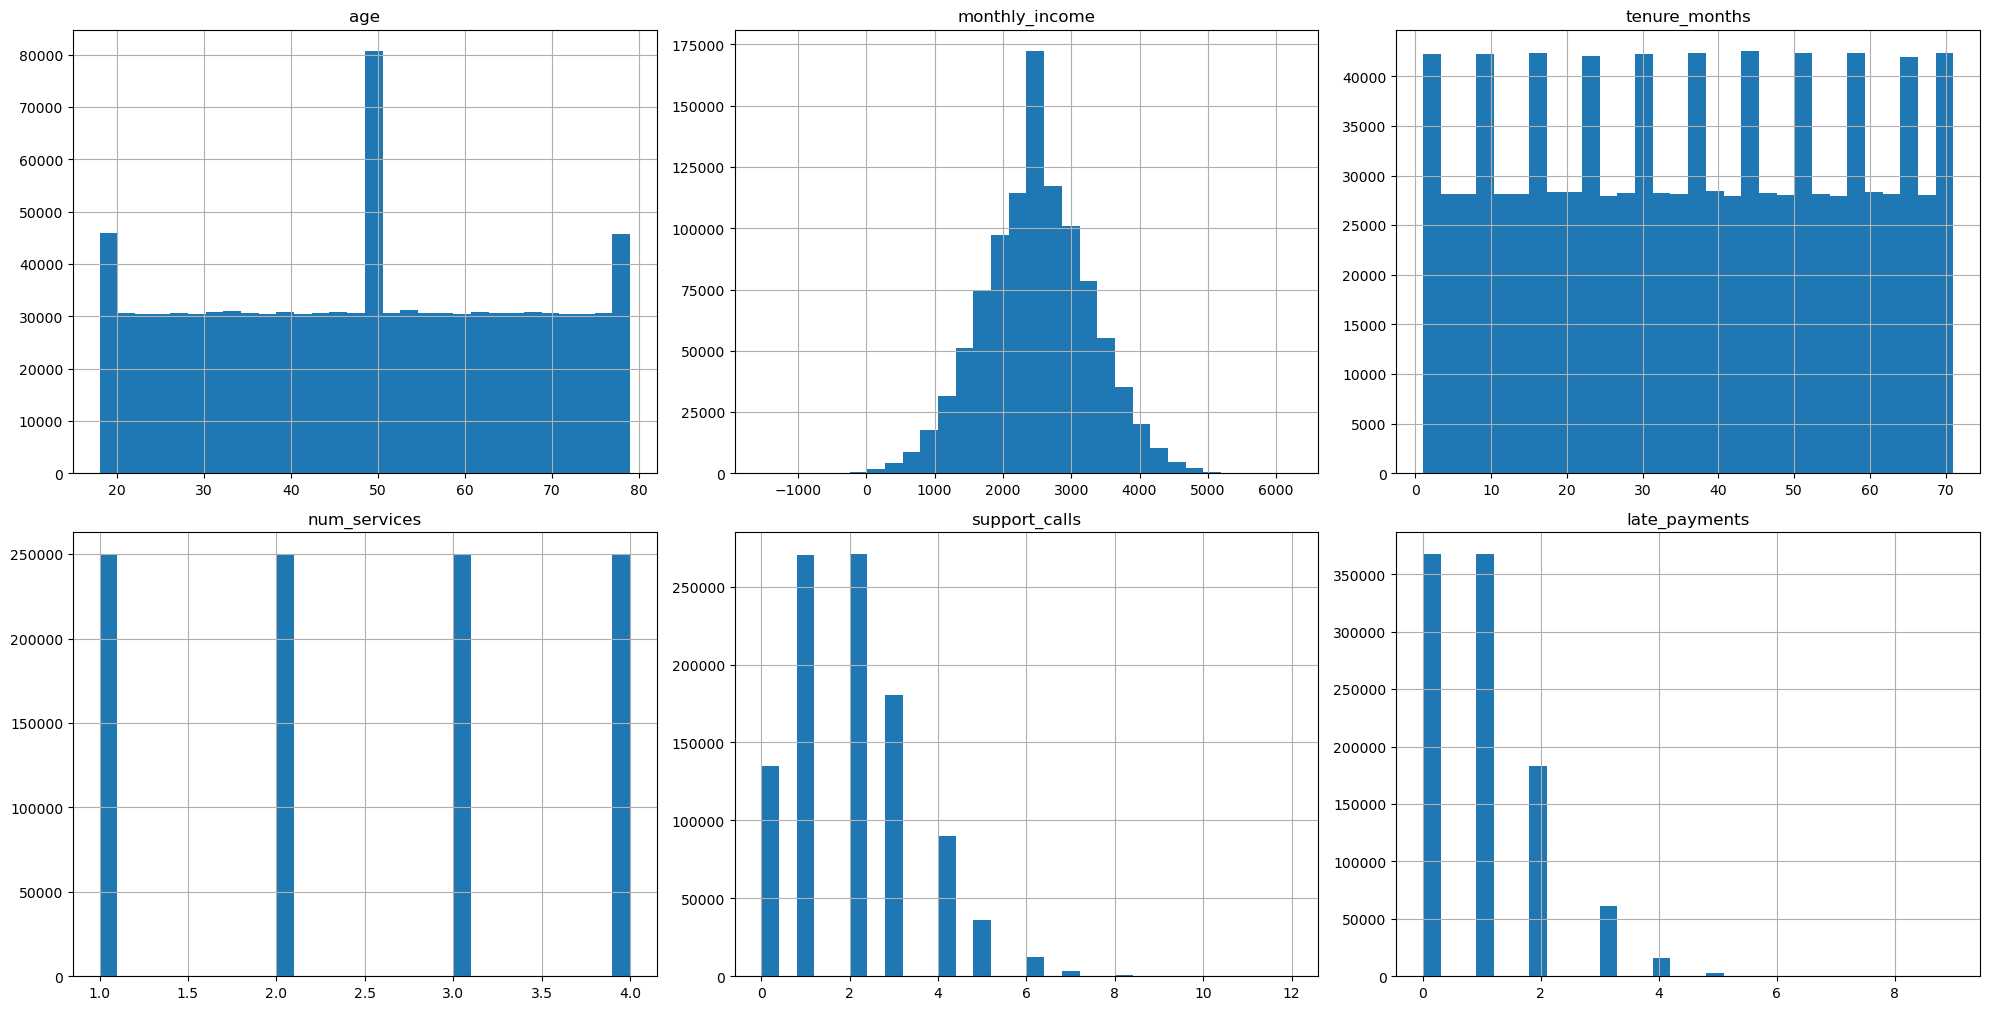

In [19]:
graficos_exploratorios = df.drop(["customer_id","last_interaction_date", "churn"], axis = 1)
graficos_exploratorios.hist(figsize = (20,15), layout = (3,3),bins = 30)
plt.tight_layout();

## Análisis Exploratorio de Datos (EDA) preliminar sobre el comportamiento de los clientes y la deserción (churn)
1. Perfil Demográfico y de UsoAge (Edad): La distribución es notablemente uniforme entre los 20 y 80 años, con un pico atípico y muy pronunciado cerca de los 50 años. Esto sugiere un posible sesgo en la recolección de datos o un segmento de mercado muy específico que debe ser investigado.Monthly Income: Sigue una distribución normal (campana de Gauss) centrada aproximadamente en las 2,500 unidades monetarias. La mayoría de los clientes tienen ingresos medios, con pocos casos en los extremos.Tenure Months: Presenta una distribución uniforme con caídas periódicas. Esto indica una base de clientes constante en antigüedad, pero con puntos de fuga regulares (posiblemente al finalizar contratos mensuales o anuales).2. Comportamiento del ServicioNum Services: Es una variable categórica (1 a 4 servicios). La distribución es equilibrada, lo que indica que no hay un paquete de servicios que predomine sobre los demás.Support Calls: La distribución tiene un sesgo positivo (a la derecha). La mayoría de los clientes realizan entre 0 y 3 llamadas. Un volumen superior a 5 llamadas es poco frecuente pero crítico para el análisis de satisfacción.Late Payments: Al igual que las llamadas, está sesgada a la derecha. La gran mayoría de los clientes no tienen pagos atrasados o tienen máximo uno, lo cual es un indicador de salud financiera en la cartera.

# Análisis de correlación entre variables

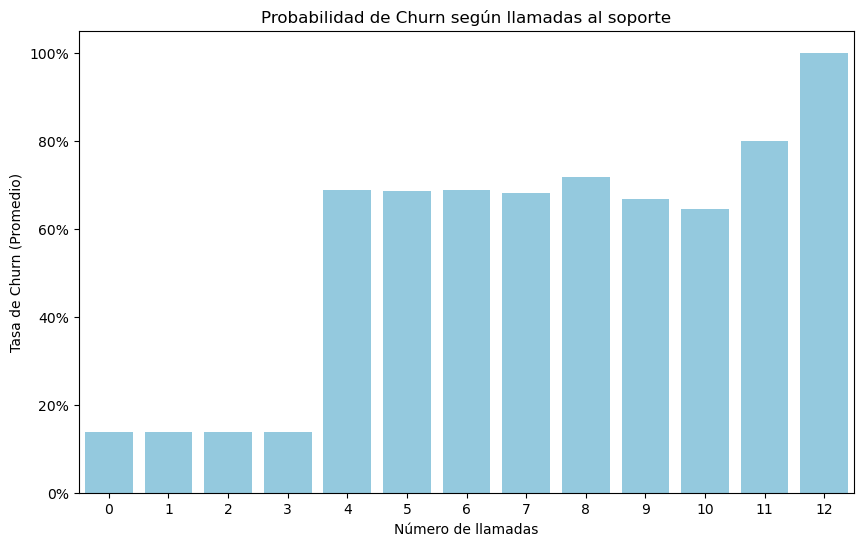

In [20]:
# Churn: The rate at which customers stop doing business with a company or cancel their subscriptions within a specific period
plt.figure(figsize=(10, 6))
sns.barplot(x='support_calls', y='churn', data=df, errorbar=None, color='skyblue')
plt.ylabel('Tasa de Churn (Promedio)')
plt.xlabel('Número de llamadas')
# poniendo porcentajes en el eje Y
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.savefig("C:/Users/G_Ardila/OneDrive/Desktop/Regresión_logística/imagenes/probabilidad_churn.png", dpi=300, bbox_inches="tight")
plt.title('Probabilidad de Churn según llamadas al soporte');

## Análisis del gráfico churn vs support calls
1. El "Punto de Quiebre" (Umbral Crítico)Existe un salto drástico y alarmante entre las 3 y 4 llamadas.Hasta 3 llamadas: La tasa de churn es baja y estable (aprox. 15%). Esto sugiere que los problemas iniciales son normales o se resuelven satisfactoriamente.A partir de la 4ª llamada: El riesgo se dispara a casi el 70%. Esto indica que si un cliente necesita llamar una cuarta vez, es muy probable que ya esté frustrado y considerando irse.2. Zona de Fatiga (4 a 10 llamadas)Entre las 4 y 10 llamadas, la probabilidad de churn se mantiene en una meseta alta (entre 60% y 70%).Esto sugiere que, una vez que el cliente entra en un ciclo de problemas no resueltos, el soporte adicional no está logrando "recuperar" su confianza, solo mantiene la incertidumbre.3. El Punto de No Retorno (11+ llamadas)A partir de la llamada 11, la tasa vuelve a subir hasta llegar al 100% en la llamada 12.Para este punto, el cliente está prácticamente fuera. La relación está totalmente rota.

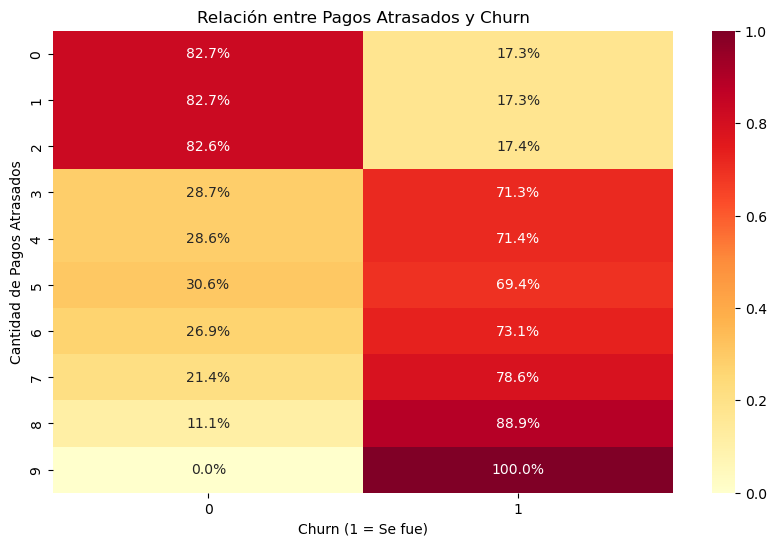

In [21]:
# Creamos la tabla de contingencia, Cuenta cuántas veces ocurre cada combinación. Por ejemplo: "¿Cuántos clientes tienen 3 pagos atrasados y SÍ se fueron?
# Al poner "index", Python divide los valores por el total de cada fila.
tabla_contingencia = pd.crosstab(df["late_payments"], df["churn"], normalize = "index")

plt.figure(figsize = (10,6))
sns.heatmap(tabla_contingencia, annot = True, fmt = ".1%", cmap = "YlOrRd")
plt.title('Relación entre Pagos Atrasados y Churn')
plt.xlabel('Churn (1 = Se fue)')
plt.savefig("C:/Users/G_Ardila/OneDrive/Desktop/Regresión_logística/imagenes/pagos_churn.png", dpi=300, bbox_inches="tight")
plt.ylabel('Cantidad de Pagos Atrasados');

## Análisis relación pagos atrasados y posibilidad que el cliente abandone la empresa
Los pagos atrasados son un predictor de abandono "binario". Hasta los 2 pagos el riesgo es bajo, pero a partir del tercer pago atrasado, el cliente entra en una "zona de peligro" donde tienes más del 70% de probabilidades de perderlo.

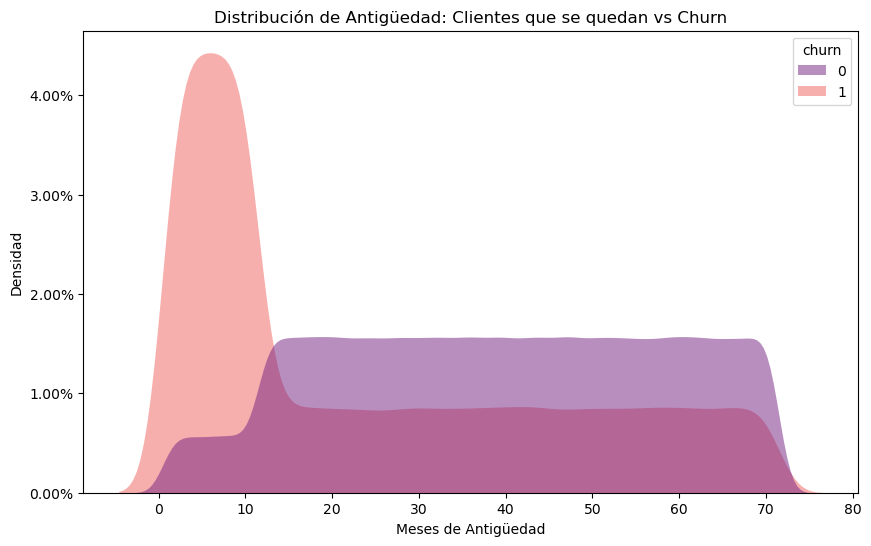

In [22]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data = df, x="tenure_months", hue = "churn", fill = True, common_norm=False, palette='magma', alpha=.5, linewidth=0)
plt.title('Distribución de Antigüedad: Clientes que se quedan vs Churn')
# poniendo porcentajes en el eje Y
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.savefig("C:/Users/G_Ardila/OneDrive/Desktop/Regresión_logística/imagenes/tenure_churn.png", dpi=300, bbox_inches="tight")
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Densidad');

## Antigüedad en la empresa vs churn
1. La Crisis del Primer Año (Infancia del Cliente). El pico masivo de color rosa entre los 0 y 12 meses indica una "mortalidad infantil" altísima en la base de clientes. La gran mayoría de las cancelaciones ocurren casi inmediatamente después de la contratación. Lectura: Hay algo que decepciona al cliente muy rápido. Puede ser que la promesa de ventas no coincida con la realidad, un proceso de instalación/bienvenida (onboarding) deficiente, o que los contratos sean mensuales y fáciles de cancelar.
2. El "Valle de Estabilidad" (Clientes Maduros). Se observa que a partir del mes 12-15, la montaña rosa cae drásticamente y se vuelve plana y baja. Esto significa que si se logra que un cliente supere el primer año, la probabilidad de que se vaya es mínima y constante. La montaña morada es dominante y estable desde el mes 15 hasta el 70. Se tiene una base de clientes leales muy sólida, pero cuesta mucho "fabricarlos" debido a la fuga inicial.

# Planteamiento de estrategio o recomendaciones

## Estrategia de Retención Proactiva y Mitigación de Churn
Basado en el análisis de correlación y comportamiento de los clientes, se proponen las siguientes líneas de acción para reducir la tasa de deserción y fortalecer la lealtad de la cartera.
### 1. Gestión de Soporte Crítico (Regla de las 3 Llamadas)
Acción: Implementar un sistema de alerta temprana que se dispare cuando un cliente realiza su tercera llamada de soporte.Objetivo: Evitar que el cliente llegue a la cuarta llamada, donde el riesgo de abandono salta del 15% al 70%.Táctica: El ticket de la tercera llamada debe ser escalado automáticamente a un "Equipo de Respuesta Especializada" con mayor capacidad resolutiva y facultades para ofrecer compensaciones inmediatas.
### 2. Programa de Blindaje del Primer Año (Onboarding)
Acción: Rediseñar la experiencia del cliente durante los primeros 12 meses de antigüedad.Objetivo: Suavizar el pico de "mortalidad infantil" detectado en el análisis de tenure.Táctica: Crear un programa de Check-ins automáticos (mes 1, 3 y 6) para asegurar que el cliente está logrando el valor esperado. Si el cliente supera los 15 meses, entra en la "zona de estabilidad", por lo que los esfuerzos deben concentrarse intensamente antes de este hito.
### 3. Intervención en Cartera Vencida (Umbral de Pago)
Acción: Ejecutar protocolos de cobranza preventiva y amigable antes de que el cliente acumule el tercer pago atrasado.Objetivo: Evitar que el cliente cruce el umbral del 70% de probabilidad de churn vinculado a la morosidad.Táctica: Ofrecer planes de pago o facilidades de refinanciamiento al detectar el segundo retraso consecutivo, tratando el problema como un riesgo de pérdida de cliente y no solo como una deuda financiera.
### 4. Optimización de Recursos de Marketing
Acción: Despriorizar campañas de fidelización masivas para clientes de alta antigüedad (más de 2 años).Objetivo: Eficiencia presupuestaria.Táctica: Dado que la probabilidad de churn en este segmento es mínima y constante, el presupuesto debe ser reasignado a incentivos de permanencia para clientes nuevos (mes 1 al 12), donde el impacto en la retención será significativamente mayor.


# Modelo de regresión logística

In [23]:
# Normalizar datos
scaler = StandardScaler()
cols_to_scale = ["tenure_months","support_calls", "late_payments"]
normado = scaler.fit_transform(df[cols_to_scale])
df_normado = pd.DataFrame(data = normado, columns = cols_to_scale)
df_normado["churn"] = df["churn"]

In [24]:
# Variables dependientes e independientes
X = df_normado.drop("churn", axis = 1)
y = df_normado["churn"]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, random_state = 42)

# crear y entrenar el modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
modelo.score(X_test,y_test )

0.826565

## Gráficos de precisión logística con ajuste en el modelo de predicción

In [26]:
# Realizar predicciones usando el conjunto de de prueba
predicciones_logistica = modelo.predict(X_test)

Text(0.5, 1.0, 'Matriz de Confusión: Modelo de Retención')

<Figure size 800x600 with 0 Axes>

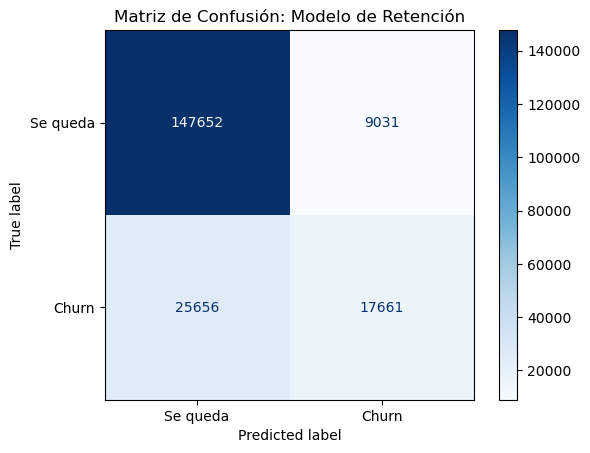

In [27]:
# Crear gráfico para validar precisión del modelo
 #Generar la matriz
cm = confusion_matrix(y_test, predicciones_logistica)

# Graficar
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se queda', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión: Modelo de Retención');

In [33]:
#Generar reporte
reporte = classification_report(y_test, predicciones_logistica, target_names = ['Se queda', 'Churn'])
print("Reporte de Clasificación:\n")
print(reporte)

Reporte de Clasificación:

              precision    recall  f1-score   support

    Se queda       0.85      0.94      0.89    156683
       Churn       0.66      0.41      0.50     43317

    accuracy                           0.83    200000
   macro avg       0.76      0.68      0.70    200000
weighted avg       0.81      0.83      0.81    200000



Para ajustar el umbral, necesitamos dejar de usar .predict() (que usa 0.5 por defecto) y empezar a usar .predict_proba(), que nos da la probabilidad exacta (de 0 a 1) que el modelo le asigna a cada cliente.Como vimos que el modelo es muy "tímido" para marcar el Churn, vamos a bajar el umbral a 0.3. Esto significa que si el modelo tiene apenas un 30% de sospecha de que alguien se va, lo marcaremos como alerta.

In [34]:
# 1. Obtenemos las probabilidades de la clase 1 (Churn)
# predict_proba devuelve [prob_quedarse, prob_churn]
probabilidades = modelo.predict_proba(X_test)[:,1]
# 2. Definimos el nuevo umbral (Threshold)
nuevo_umbral = 0.3
# 3. Aplicamos el umbral manualmente
predicciones_ajustadas = (probabilidades >= nuevo_umbral).astype(int)
print(f"Reporte con Umbral de {nuevo_umbral}:\n")
print(classification_report(y_test, predicciones_ajustadas, target_names=['Se queda', 'Churn']))


Reporte con Umbral de 0.3:

              precision    recall  f1-score   support

    Se queda       0.89      0.84      0.87    156683
       Churn       0.52      0.64      0.57     43317

    accuracy                           0.80    200000
   macro avg       0.71      0.74      0.72    200000
weighted avg       0.81      0.80      0.80    200000



<Figure size 800x600 with 0 Axes>

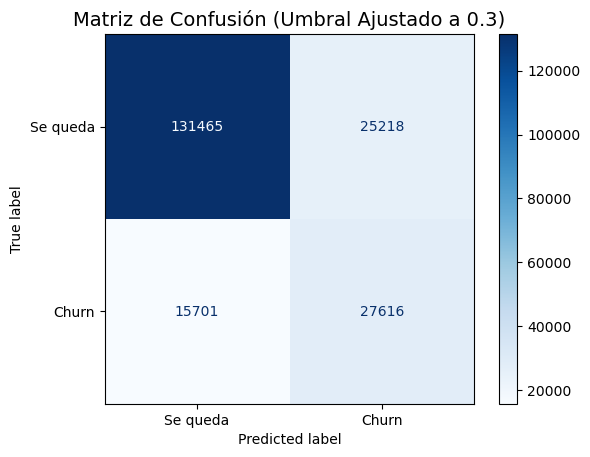

In [41]:
# Generar la nueva matriz con las predicciones del umbral 0.3
cm_ajustada = confusion_matrix(y_test, predicciones_ajustadas)

# Graficar
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ajustada, display_labels=['Se queda', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.savefig("C:/Users/G_Ardila/OneDrive/Desktop/Regresión_logística/imagenes/matriz_confusion.png", dpi=300, bbox_inches="tight")
plt.title(f'Matriz de Confusión (Umbral Ajustado a {nuevo_umbral})', fontsize=14);


## Optimización del Modelo: Calibración del Umbral de Decisión
Tras evaluar el modelo de Regresión Logística inicial, se procedió a realizar un ajuste en el umbral de decisión (threshold) para alinear las predicciones con los objetivos comerciales de retención.
1. Evaluación del Modelo Base (Umbral 0.5)El modelo original presentaba una alta Exactitud (83%), pero una baja capacidad de detección de deserción (Recall de 41%).Diagnóstico: El modelo era demasiado "conservador". Identificaba con gran precisión a los clientes leales, pero fallaba en detectar a 6 de cada 10 clientes en riesgo, dejándolos fuera de cualquier campaña de retención.
2. Ajuste Estratégico (Umbral 0.3)Se redujo el umbral de probabilidad a 0.3 para aumentar la sensibilidad del modelo ante señales tempranas de abandono.
3. Comparativa de Resultados y Beneficios

|Métrica (Clase Churn)| |Modelo Original (0.5)| |Modelo Ajustado (0.3)| |Impacto del Ajuste|
|---------------------| |---------------------| |---------------------| |------------------|
|Recall (Detección)   | |41%                  | |64%                  | |+23% de clientes en riesgo detectados|
|F1-Score (Equilibrio)| |0.50                 | |0.57                 | |Mejora en la robustez del modelo|
|Falsos Negativos     | ~25,600               | |~15,500              | |10,000 bajas potenciales "rescatadas"|

4. Conclusión y Beneficio de NegocioAunque el ajuste conlleva una disminución en la precisión (más "falsas alarmas"), el beneficio estratégico es superior por las siguientes razones:Mayor Cobertura de Riesgo: El equipo de retención ahora tiene visibilidad sobre un 23% adicional de la población en riesgo que antes era "invisible".Reducción del Costo de Oportunidad: En este modelo de negocio, el costo de perder a un cliente (Churn) es significativamente mayor que el costo de contactar preventivamente a un cliente leal (Falso Positivo).Optimización del F1-Score: El incremento del F1-Score de 0.50 a 0.57 valida matemáticamente que el modelo es ahora más efectivo para capturar la complejidad de la deserción.

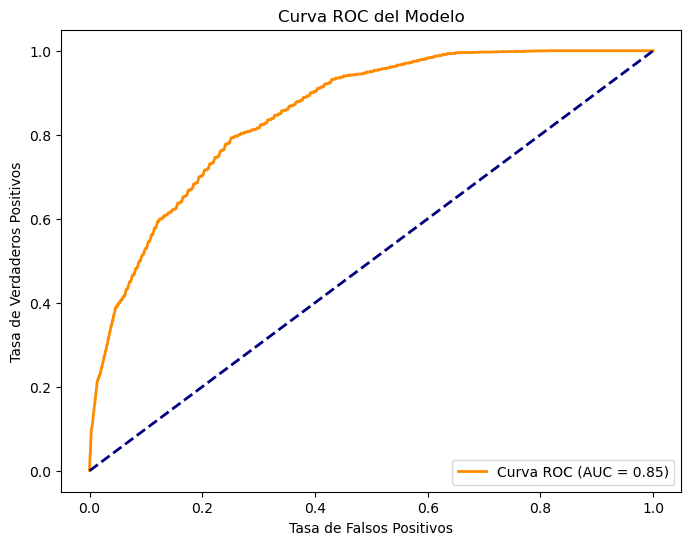

In [42]:
# Necesitamos las probabilidades, no solo la clase (0 o 1)
y_probs = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de azar
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del Modelo')
plt.savefig("C:/Users/G_Ardila/OneDrive/Desktop/Regresión_logística/imagenes/curva_ROC.png", dpi=300, bbox_inches="tight")
plt.legend(loc="lower right");

## Validación Global del Modelo: Curva ROC y Capacidad de Discriminación
La Curva ROC (Receiver Operating Characteristic) permite evaluar la capacidad del modelo para distinguir entre clientes que abandonarán la empresa (Churn) y aquellos que permanecerán leales, visualizando el equilibrio entre aciertos y falsas alarmas.
### 1. Interpretación de la Métrica AUC (0.85)
El Área Bajo la Curva (AUC) de 0.85 indica un desempeño excelente. En términos de probabilidad, esto significa que si seleccionamos al azar a un cliente que se fue y a uno que se quedó, el modelo clasificará correctamente al cliente en riesgo el 85% de las veces. Un modelo basado en el azar tendría un AUC de 0.50, por lo que nuestro modelo supera ampliamente la base de referencia.
### 2. Análisis de la CurvaSeparación de la Diagonal: 
La curva naranja se aleja significativamente de la línea punteada azul (azar), lo que demuestra una fuerte capacidad de aprendizaje de las variables de entrada (tenure, support_calls, late_payments).Zona de Optimización: La pronunciada inclinación hacia la esquina superior izquierda confirma que el modelo es capaz de alcanzar una alta tasa de detección de desertores (Verdaderos Positivos) manteniendo una tasa controlada de errores (Falsos Positivos).
### 3. Relevancia para el Negocio
Este gráfico justifica técnicamente el ajuste de umbral realizado anteriormente. Al tener una curva "robusta" (un AUC alto), el negocio tiene la libertad de mover el umbral de decisión para capturar más clientes en riesgo (subir por la curva) con la confianza de que el modelo tiene fundamentos estadísticos sólidos y no está actuando por azar.

### Probamos el modelo con fake data

In [40]:
# 1. Creamos datos de 3 clientes nuevos
# [tenure_months, support_calls, late_payments]
# Cliente fiel, cliente nuevo con problemas, cliente crítico
data_nuevos_clientes ={
    "tenure_months":[60,4,12],
    "support_calls":[1,5,8],
    "late_payments":[0,1,4]
}
df_nuevos = pd.DataFrame(data_nuevos_clientes)

#2 Normalizar con el scaler existente
# Nota: Usamos transform(), NO fit_transform() para no alterar la escala original
df_nuevos_norm = scaler.transform(df_nuevos)
# Obtener probabilidades
df_nuevos_listos = pd.DataFrame(df_nuevos_norm, columns = cols_to_scale)
probabilidades_nuevos= modelo.predict_proba(df_nuevos_listos)[:,1]
# 4 Aplicamos umbral 0.3 ó 3%
umbral = 0.3
predicciones_nuevas = (probabilidades_nuevos >= umbral).astype(int)

# 5. Mostrar resultados
for i, prob in enumerate(probabilidades_nuevos):
    resultado = "CHURN (ALERTA)" if predicciones_nuevas[i] == 1 else "SE QUEDA"
    print(f"Cliente {i+1}: Probabilidad de Churn: {prob:.2%}. Resultado: {resultado}")

Cliente 1: Probabilidad de Churn: 0.99%. Resultado: SE QUEDA
Cliente 2: Probabilidad de Churn: 88.32%. Resultado: CHURN (ALERTA)
Cliente 3: Probabilidad de Churn: 99.78%. Resultado: CHURN (ALERTA)
